# World Cup Prediction: Data Understanding and Hypothesis Log

A record of what the data contains and which features helped (or did not help) the 1X2 World Cup model.

Outline: imports, configuration, data loading, inspection, exploratory analysis, then each hypothesis as a question with a verdict.

## Imports

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "src").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.calibration import CalibratedClassifierCV

from src.worldcup import config as C
from src.worldcup.data import load_intl_results, load_wc_matches
from src.worldcup.features import build_dataset, edition_table_filled, FEATURES, _STRENGTH
from src.worldcup.model import train_eval, symmetrize, ELO_ONLY
from src.worldcup.squads import confirmed_strength_table
from src.worldcup.cross_tournament import analyse_correlation
from src.worldcup.defense_study import analyse as defense_analyse, attach_ratings, tournament_outcomes
from src.analysis.evaluation import log_loss as ll


## Configuration

In [2]:
RANDOM_STATE = 7
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 4)
print("processed outputs ->", C.OUT)


processed outputs -> /sessions/eager-affectionate-noether/mnt/predict-football/worldcup-predictor/_processed_outputs/worldcup


## Data loading

In [3]:
results = load_intl_results()
wc = load_wc_matches()
bundle_2022 = build_dataset(2022)
train_2022, test_2022 = bundle_2022["train"], bundle_2022["test"]
df_raw = results.copy()
(results.shape, wc.shape, train_2022.shape, test_2022.shape)


((49306, 15), (960, 38), (1396, 14), (64, 16))

## Initial inspection

### What does the international match data contain and how clean is it?

In [4]:
display(results.head())
info = pd.DataFrame({
    "dtype": results.dtypes.astype(str),
    "n_missing": results.isna().sum(),
    "n_unique": results.nunique(),
})
print("rows:", len(results), " duplicated rows:", int(results.duplicated().sum()))
info


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,team1,team2,is_friendly,is_shootout,result,y
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Scotland,England,True,False,D,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,England,Scotland,True,False,H,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Scotland,England,True,False,H,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,England,Scotland,True,False,D,1
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Scotland,England,True,False,H,0


rows: 49306  duplicated rows: 0


,dtype,n_missing,n_unique
date,datetime64[ns],0,16446
home_team,object,0,327
away_team,object,0,321
home_score,float64,0,26
away_score,float64,0,22
tournament,object,0,199
city,object,0,2139
country,object,0,269
neutral,bool,0,2
team1,object,0,327


## Exploratory data analysis

### What is the class balance of results, and how common are draws?

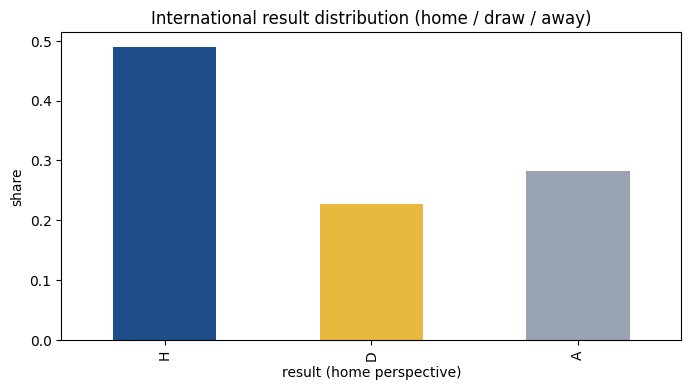

draw rate: 22.7%


,count,share
result,,
H,24163,0.490
D,11208,0.227
A,13935,0.283


In [5]:
counts = results["result"].value_counts().reindex(["H", "D", "A"])
share = (counts / counts.sum()).round(3)
ax = share.plot(kind="bar", color=["#1d4e89", "#e9b83f", "#9aa3b2"])
ax.set_title("International result distribution (home / draw / away)")
ax.set_xlabel("result (home perspective)"); ax.set_ylabel("share"); plt.show()
print("draw rate: %.1f%%" % (100 * share["D"]))
pd.DataFrame({"count": counts, "share": share})


### How are pre-tournament Elo gaps and squad ratings distributed?

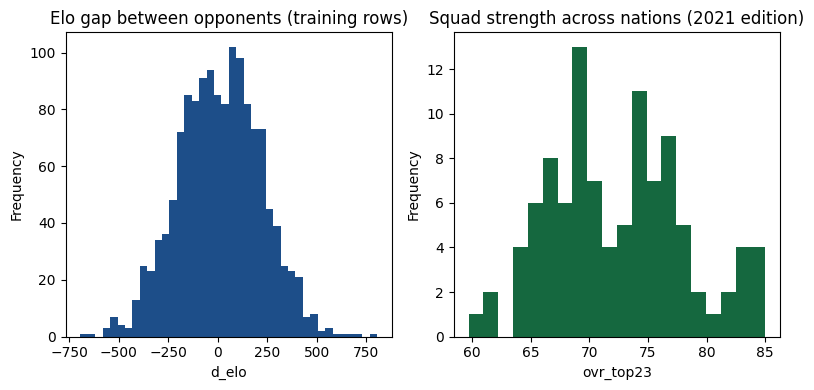

In [6]:
ed = edition_table_filled(2021)
fig, ax = plt.subplots(1, 2)
train_2022["d_elo"].plot(kind="hist", bins=40, ax=ax[0], color="#1d4e89")
ax[0].set_title("Elo gap between opponents (training rows)"); ax[0].set_xlabel("d_elo")
ed["ovr_top23"].plot(kind="hist", bins=20, ax=ax[1], color="#15683f")
ax[1].set_title("Squad strength across nations (2021 edition)"); ax[1].set_xlabel("ovr_top23")
plt.tight_layout(); plt.show()


### Has the home / draw / away split been stable over recent decades?

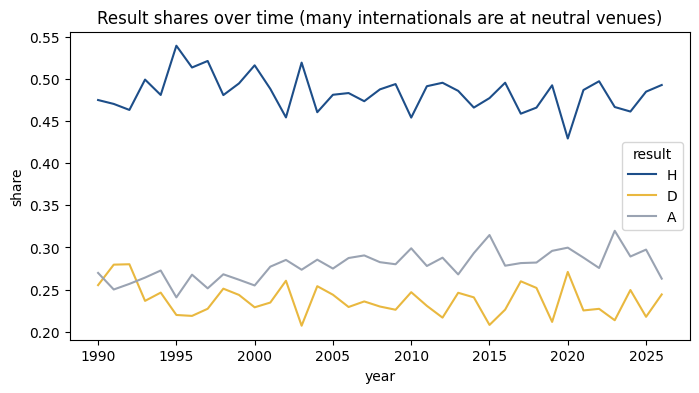

In [7]:
years = results.assign(year=results["date"].dt.year)
yr = (years[years["year"] >= 1990]
      .groupby("year")["result"].value_counts(normalize=True)
      .unstack().reindex(columns=["H", "D", "A"]))
yr.plot(color=["#1d4e89", "#e9b83f", "#9aa3b2"])
plt.title("Result shares over time (many internationals are at neutral venues)")
plt.ylabel("share"); plt.xlabel("year"); plt.show()


## Hypotheses tested

### Does adding EA FC squad strength improve on an Elo-only model?

In [8]:
res18 = train_eval(2018)["results"].assign(world_cup=2018)
res22 = train_eval(2022)["results"].assign(world_cup=2022)
h1 = pd.concat([res18, res22], ignore_index=True)
h1 = h1[["world_cup", "model", "log_loss", "brier", "accuracy"]].round(4)
h1


,world_cup,model,log_loss,brier,accuracy
0,2018,full (Elo + FIFA strength),0.9497,0.5647,0.5625
1,2018,baseline: Elo-only,0.9866,0.5836,0.5156
2,2018,baseline: class-prior,1.1050,0.6722,0.3906
3,2022,full (Elo + FIFA strength),1.0109,0.5961,0.5625
4,2022,baseline: Elo-only,1.0324,0.6140,0.5469
5,2022,baseline: class-prior,1.0634,0.6429,0.4531


Verdict: yes - the full model beats Elo-only on log-loss in both World Cups, so EA FC squad strength is the key added feature.

### Does recent form add anything once Elo is already in the model?

In [9]:
corr = analyse_correlation().set_index("predictor")
recent_r = corr.loc["recent competitive ppg (24m)", "pearson"]
elo_r = corr.loc["pre-tournament Elo (benchmark)", "pearson"]
print("recent form vs World Cup points-per-game: pearson %+.3f" % recent_r)
print("Elo        vs World Cup points-per-game: pearson %+.3f" % elo_r)


recent form vs World Cup points-per-game: pearson +0.091
Elo        vs World Cup points-per-game: pearson +0.516


Verdict: no - recent form barely correlates with tournament success while Elo correlates strongly, so form is redundant with Elo.

### Does flagging African (CAF) teams help or hurt the model?

In [10]:
CAF = {"Senegal", "Morocco", "Tunisia", "Cameroon", "Ghana", "Nigeria", "Egypt",
       "Algeria", "Ivory Coast", "Mali", "South Africa", "Cape Verde",
       "Burkina Faso", "Congo DR", "DR Congo"}
def caf_dummy(df):
    return df["team1"].isin(CAF).astype(int) - df["team2"].isin(CAF).astype(int)

def test_logloss(tr, te, feats):
    sym = symmetrize(tr, feats)
    m = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    m.fit(sym[feats], sym["y"])
    return ll(m.predict_proba(te[feats]), te["y"].to_numpy())


In [11]:
h3 = []
for yr in (2018, 2022):
    d = build_dataset(yr)
    tr, te = d["train"].copy(), d["test"].copy()
    tr["d_caf"], te["d_caf"] = caf_dummy(tr), caf_dummy(te)
    base = test_logloss(tr, te, list(FEATURES))
    with_caf = test_logloss(tr, te, list(FEATURES) + ["d_caf"])
    h3.append({"world_cup": yr, "log_loss_base": base,
               "log_loss_with_caf": with_caf, "delta": with_caf - base})
h3 = pd.DataFrame(h3).round(4)
h3


,world_cup,log_loss_base,log_loss_with_caf,delta
0,2018,0.9500,0.9649,0.0149
1,2022,1.0228,1.0158,-0.0071


Verdict: no consistent gain - the CAF flag helps marginally in 2022 but hurts in 2018, so it is noise rather than a stable signal and was left out.

### Do confirmed 26-man squads change the favourites versus a top-23 nationality proxy?

In [12]:
conf, rep = confirmed_strength_table()
proxy = edition_table_filled(2026)
cmp = pd.DataFrame({"proxy_ovr23": proxy["ovr_top23"],
                    "confirmed_ovr23": conf["ovr_top23"]}).dropna()
cmp["delta"] = (cmp["confirmed_ovr23"] - cmp["proxy_ovr23"]).round(1)
cmp.loc[["Spain", "France", "Brazil", "Argentina", "England"]].round(1)


,proxy_ovr23,confirmed_ovr23,delta
Spain,85.0,84.0,-1.0
France,85.2,84.0,-1.2
Brazil,83.9,78.7,-5.3
Argentina,82.7,82.0,-0.7
England,84.0,82.3,-1.7


Verdict: yes - confirmed squads pull deep nations (Spain, Brazil) below their nationality-pool proxy, which changes who the model rates as favourite.

### Does sigmoid (Platt) or isotonic calibration give better probabilities on a small tournament?

In [13]:
def fit_cal(method, tr, te, feats):
    tr = tr.sort_values("date").reset_index(drop=True)
    cut = int(len(tr) * 0.85)
    base = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    fit_sym = symmetrize(tr.iloc[:cut], feats)
    base.fit(fit_sym[feats], fit_sym["y"])
    cal = CalibratedClassifierCV(base, method=method, cv="prefit")
    cal_sym = symmetrize(tr.iloc[cut:], feats)
    cal.fit(cal_sym[feats], cal_sym["y"])
    p = cal.predict_proba(te[feats])
    return ll(p, te["y"].to_numpy()), float(p[:, 1].min())


In [14]:
h5 = []
for yr in (2018, 2022):
    d = build_dataset(yr)
    te = d["test"]
    s_ll, s_min = fit_cal("sigmoid", d["train"], te, list(FEATURES))
    i_ll, i_min = fit_cal("isotonic", d["train"], te, list(FEATURES))
    h5.append({"world_cup": yr, "sigmoid_logloss": s_ll, "isotonic_logloss": i_ll,
               "isotonic_min_draw_p": i_min, "sigmoid_min_draw_p": s_min})
h5 = pd.DataFrame(h5).round(4)
h5


,world_cup,sigmoid_logloss,isotonic_logloss,isotonic_min_draw_p,sigmoid_min_draw_p
0,2018,0.9545,2.1354,0.0,0.2464
1,2022,1.0109,0.9917,0.0,0.2153


Verdict: sigmoid is the safer choice - isotonic drives the draw probability to zero and its log-loss explodes to 2.14 in 2018, while sigmoid keeps a floor and stays stable across both World Cups.

### Does a strong defence (goalkeeper plus defenders) win tournaments beyond overall quality?

In [15]:
study = defense_analyse(attach_ratings(tournament_outcomes()))
print("rows %d, tournaments %d, champions %d" %
      (study["n_rows"], study["n_instances"], study["n_champions"]))
print("overall        vs PPG: r=%+.3f p=%.3f" % study["corr_overall_ppg"])
print("defensive line vs PPG: r=%+.3f p=%.3f" % study["corr_defline_ppg"])
print("defence TILT   vs PPG: r=%+.3f p=%.3f" % study["corr_deftilt_ppg"])
print("champions defence tilt %.2f vs field %.2f" %
      (study["champ_mean_def_tilt"], study["field_mean_def_tilt"]))


rows 289, tournaments 19, champions 15
overall        vs PPG: r=+0.576 p=0.000
defensive line vs PPG: r=+0.571 p=0.000
defence TILT   vs PPG: r=-0.104 p=0.077
champions defence tilt -0.06 vs field 0.79


Verdict: no - defence correlates with success only because good teams have good defenders, and defence tilt net of overall quality shows no edge.

### Does continental-tournament form (Euro, Copa) predict World Cup performance?

In [16]:
analyse_correlation().round(3)


,predictor,n,pearson,spearman
0,continental campaign ppg,195,-0.020,-0.047
1,recent competitive ppg (24m),221,0.091,0.086
2,pre-tournament Elo (benchmark),224,0.516,0.534


Verdict: no - continental campaign points-per-game is essentially uncorrelated with World Cup performance, while pre-tournament Elo carries the signal.

### Should host advantage apply to non-host teams at a neutral World Cup?

In [17]:
wc_hf = test_2022[["team1", "team2", "home_field"]]
host_rows = wc_hf[wc_hf["home_field"] != 0]
host_teams = sorted(set(host_rows["team1"]) | set(host_rows["team2"]))
print("World Cup 2022 test matches with a home edge: %d of %d" % (len(host_rows), len(wc_hf)))
print("teams appearing in those matches:", host_teams)


World Cup 2022 test matches with a home edge: 3 of 64
teams appearing in those matches: ['Ecuador', 'Netherlands', 'Qatar', 'Senegal']


Verdict: hosts only - inside the World Cup only the host nation carries a home edge, which is correct because every other team plays at a neutral venue.

## Feature scorecard

In [18]:
scorecard = pd.DataFrame([
    ("EA FC squad strength", "Beats Elo-only?", "WORKED",
     "log-loss %.3f vs %.3f (2022)" % (
         res22.set_index("model").loc["full (Elo + FIFA strength)", "log_loss"],
         res22.set_index("model").loc["baseline: Elo-only", "log_loss"])),
    ("Recent form (24m ppg)", "Adds beyond Elo?", "NO",
     "pearson %+.2f vs Elo %+.2f" % (recent_r, elo_r)),
    ("Confederation (CAF) flag", "Helps African teams?", "NO (noise)",
     "log-loss change %+.3f (2018), %+.3f (2022)" % (
         h3.set_index("world_cup").loc[2018, "delta"],
         h3.set_index("world_cup").loc[2022, "delta"])),
    ("Confirmed 26-man squads", "Changes favourites?", "MATTERS",
     "deep nations fall below nationality proxy"),
    ("Sigmoid calibration", "Better than isotonic?", "SIGMOID",
     "isotonic %.2f log-loss in 2018 (draw p -> 0)" %
     h5.set_index("world_cup").loc[2018, "isotonic_logloss"]),
    ("Defensive tilt", "Wins titles beyond quality?", "NO",
     "tilt r=%+.2f (ns)" % study["corr_deftilt_ppg"][0]),
    ("Continental form", "Predicts the World Cup?", "NO",
     "pearson near zero"),
    ("Host advantage", "Apply to non-hosts?", "HOSTS ONLY",
     "home edge only for host nations"),
], columns=["feature", "question", "verdict", "evidence"])
scorecard.to_csv(C.OUT / "feature_scorecard.csv", index=False)
scorecard


,feature,question,verdict,evidence
0,EA FC squad strength,Beats Elo-only?,WORKED,log-loss 1.011 vs 1.032 (2022)
1,Recent form (24m ppg),Adds beyond Elo?,NO,pearson +0.09 vs Elo +0.52
2,Confederation (CAF) flag,Helps African teams?,NO (noise),"log-loss change +0.015 (2018), -0.007 (2022)"
3,Confirmed 26-man squads,Changes favourites?,MATTERS,deep nations fall below nationality proxy
4,Sigmoid calibration,Better than isotonic?,SIGMOID,isotonic 2.14 log-loss in 2018 (draw p -> 0)
5,Defensive tilt,Wins titles beyond quality?,NO,tilt r=-0.10 (ns)
6,Continental form,Predicts the World Cup?,NO,pearson near zero
7,Host advantage,Apply to non-hosts?,HOSTS ONLY,home edge only for host nations


## Conclusion

Squad strength plus Elo is the engine; form, a confederation flag, defensive tilt, and continental form add no usable signal, and probabilities are calibrated with sigmoid scaling.